# **1. Perkenalan Dataset**

**Nama dataset:** Telco Customer Churn

**Sumber:** Kaggle — https://www.kaggle.com/datasets/abbas829/telco-customer-churn-dataset

**Jumlah data:** 7.043 baris, 21 kolom

**Deskripsi fitur:**
- `customerID` — ID unik pelanggan
- `gender` — Jenis kelamin pelanggan
- `SeniorCitizen` — Apakah pelanggan adalah warga senior (1/0)
- `Partner`, `Dependents` — Status pasangan dan tanggungan
- `tenure` — Lama berlangganan (bulan)
- `PhoneService`, `MultipleLines`, `InternetService`, dll. — Layanan yang digunakan
- `Contract` — Jenis kontrak (bulanan, 1 tahun, 2 tahun)
- `MonthlyCharges`, `TotalCharges` — Biaya tagihan
- **`Churn`** — Target: apakah pelanggan berhenti berlangganan (Yes=1, No=0)

# **2. Import Library**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Utility
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')

print(f'Telco-Customer-Churn')
print(f'Jumlah baris  : {df.shape[0]}')
print(f'Jumlah kolom  : {df.shape[1]}')
print()
print('5 baris pertama:')
df.head()

Telco-Customer-Churn
Jumlah baris  : 7043
Jumlah kolom  : 21

5 baris pertama:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Informasi umum dataset
print('Informasi Dataset:')
df.info()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 

In [4]:
# Statistik deskriptif
print('Statistik Deskriptif:')
df.describe(include='all')

Statistik Deskriptif:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


# **4. Exploratory Data Analysis (EDA)**

In [5]:
# 4.1 Cek Missing Values
print('Missing Values')

# Konversi TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing = df.isnull().sum()
print(f'Total missing values: {missing.sum()}')
print(missing[missing > 0])

Missing Values
Total missing values: 11
TotalCharges    11
dtype: int64


In [6]:
# 4.2 Cek Duplikasi
print('Data Duplikat')
duplicates = df.duplicated().sum()
print(f'Jumlah baris duplikat: {duplicates}')

Data Duplikat
Jumlah baris duplikat: 0


Distribusi Target: Churn
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Persentase Churn 'No'  : 73.5%
Persentase Churn 'Yes' : 26.5%


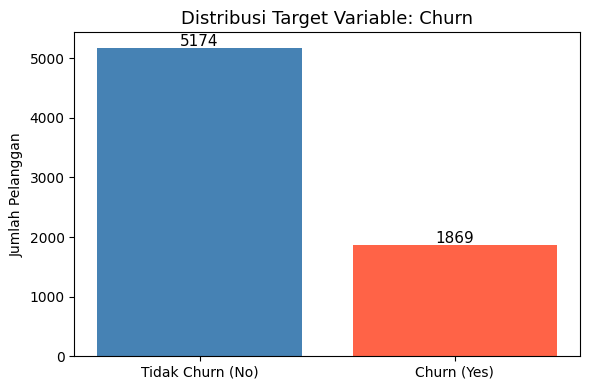

In [7]:
# 4.3 Distribusi Target Variable (Churn)
print('Distribusi Target: Churn')
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print()
print(f"Persentase Churn 'No'  : {churn_counts['No']/len(df)*100:.1f}%")
print(f"Persentase Churn 'Yes' : {churn_counts['Yes']/len(df)*100:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Tidak Churn (No)', 'Churn (Yes)'], churn_counts.values,
              color=['steelblue', 'tomato'])
ax.set_title('Distribusi Target Variable: Churn', fontsize=13)
ax.set_ylabel('Jumlah Pelanggan')
for bar, val in zip(bars, churn_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

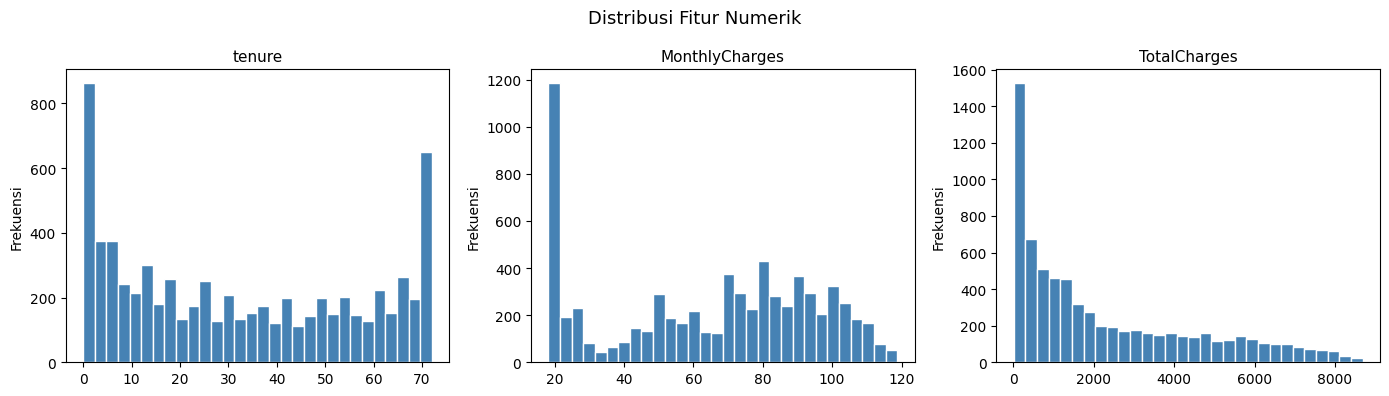

In [8]:
# 4.4 Distribusi Fitur Numerik
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Fitur Numerik', fontsize=13)
plt.tight_layout()
plt.show()

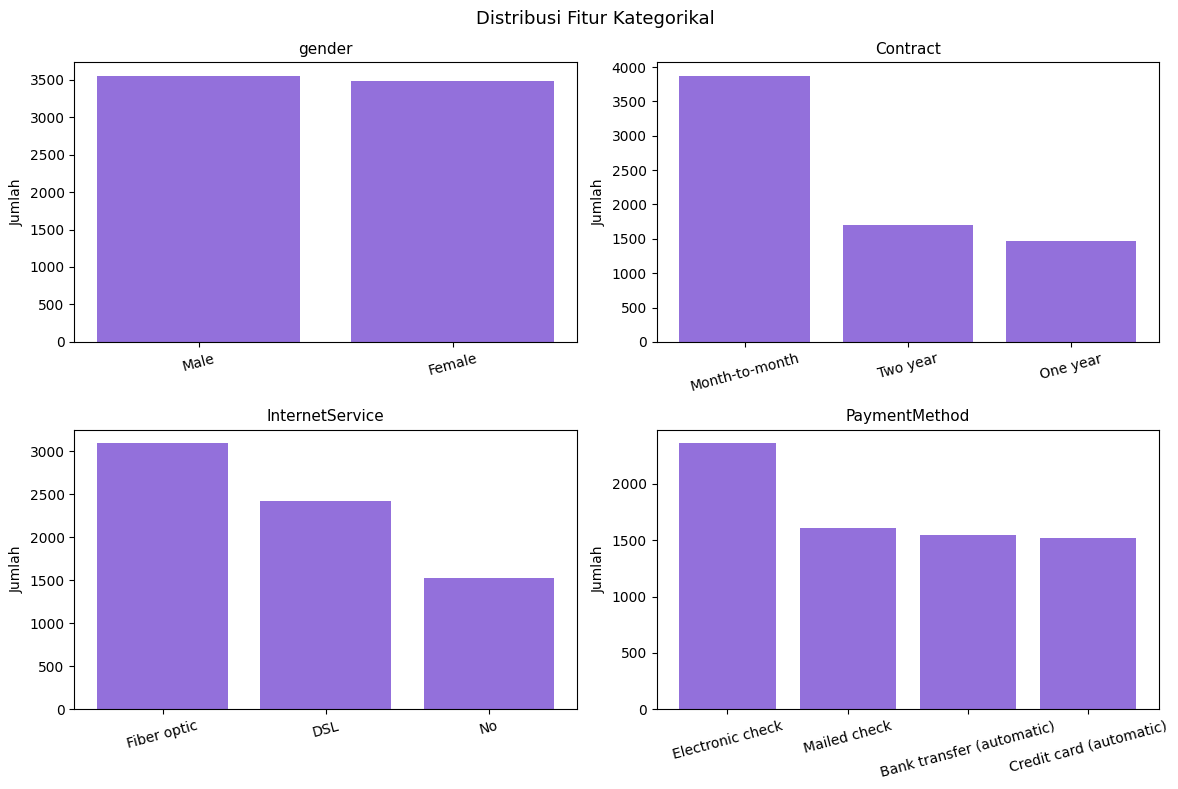

In [9]:
# 4.5 Distribusi Fitur Kategorikal
cat_cols = ['gender', 'Contract', 'InternetService', 'PaymentMethod']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='mediumpurple')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=13)
plt.tight_layout()
plt.show()

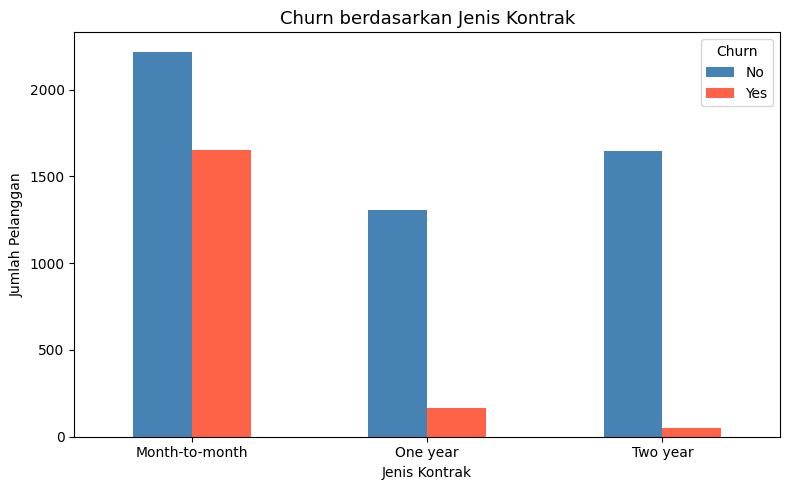

In [10]:
# 4.6 Churn berdasarkan Jenis Kontrak
fig, ax = plt.subplots(figsize=(8, 5))
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Churn berdasarkan Jenis Kontrak', fontsize=13)
ax.set_xlabel('Jenis Kontrak')
ax.set_ylabel('Jumlah Pelanggan')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Churn')
plt.tight_layout()
plt.show()

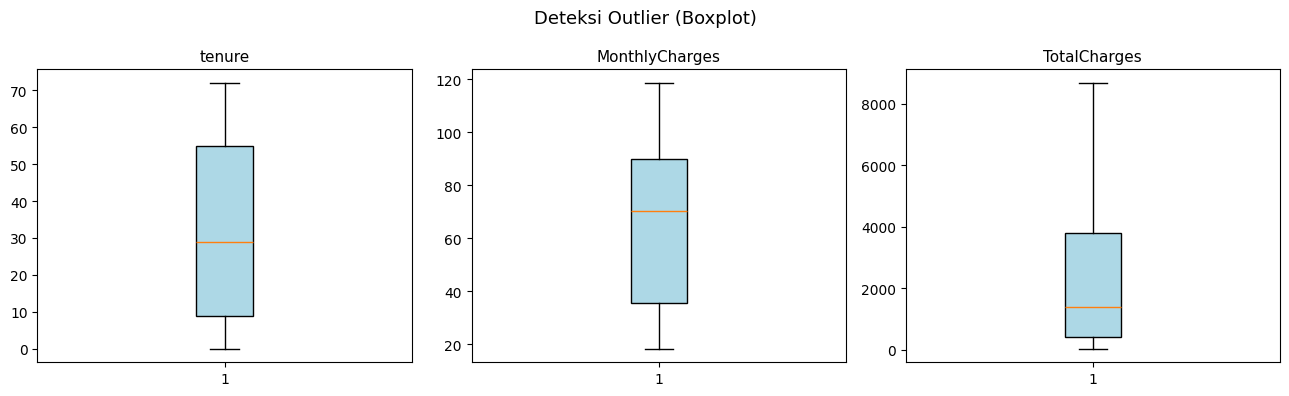

In [11]:
# 4.7 Deteksi Outlier
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(col, fontsize=11)

plt.suptitle('Deteksi Outlier (Boxplot)', fontsize=13)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Berdasarkan hasil EDA, berikut langkah preprocessing yang akan dilakukan:
1. Menghapus kolom `customerID` (tidak relevan untuk model)
2. Mengkonversi `TotalCharges` ke numerik dan menangani missing values
3. Menghapus data duplikat
4. Encoding fitur kategorikal menggunakan Label Encoding
5. Normalisasi fitur numerik menggunakan StandardScaler
6. Menyimpan dataset hasil preprocessing

In [12]:
# Salin dataframe
df_processed = df.copy()
print(f'Shape awal: {df_processed.shape}')

Shape awal: (7043, 21)


In [13]:
# 5.1 Hapus Kolom customerID
df_processed.drop(columns=['customerID'], inplace=True)
print('Kolom customerID dihapus.')
print(f'Shape sekarang: {df_processed.shape}')

Kolom customerID dihapus.
Shape sekarang: (7043, 20)


In [14]:
# 5.2 Konversi TotalCharges & Tangani Missing Values
df_processed['TotalCharges'] = pd.to_numeric(df_processed['TotalCharges'], errors='coerce')

before = len(df_processed)
df_processed.dropna(subset=['TotalCharges'], inplace=True)
after = len(df_processed)

print(f'Baris dihapus karena TotalCharges kosong: {before - after}')
print(f'Missing values tersisa: {df_processed.isnull().sum().sum()}')

Baris dihapus karena TotalCharges kosong: 11
Missing values tersisa: 0


In [15]:
# 5.3 Hapus Data Duplikat
before = len(df_processed)
df_processed.drop_duplicates(inplace=True)
after = len(df_processed)
print(f'Baris dihapus karena duplikat: {before - after}')
print(f'Shape sekarang: {df_processed.shape}')

Baris dihapus karena duplikat: 22
Shape sekarang: (7010, 20)


In [16]:
# 5.4 Encoding Fitur Kategorikal
cat_cols_to_encode = df_processed.select_dtypes(include='object').columns.tolist()
cat_cols_to_encode = [c for c in cat_cols_to_encode if c != 'Churn']

print(f'Kolom yang akan di-encode: {cat_cols_to_encode}')

le = LabelEncoder()
for col in cat_cols_to_encode:
    df_processed[col] = le.fit_transform(df_processed[col])

# Encode target: Yes=1, No=0
df_processed['Churn'] = df_processed['Churn'].map({'Yes': 1, 'No': 0})

print()
print('Distribusi target setelah encoding:')
print(df_processed['Churn'].value_counts())

Kolom yang akan di-encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Distribusi target setelah encoding:
Churn
0    5153
1    1857
Name: count, dtype: int64


In [17]:
# 5.5 Normalisasi Fitur Numerik
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
df_processed[cols_to_scale] = scaler.fit_transform(df_processed[cols_to_scale])

print('Statistik setelah normalisasi:')
df_processed[cols_to_scale].describe().round(3)

Statistik setelah normalisasi:


,tenure,MonthlyCharges,TotalCharges
count,7010.000,7010.000,7010.000
mean,-0.000,-0.000,-0.000
std,1.000,1.000,1.000
min,-1.286,-1.551,-1.002
25%,-0.959,-0.969,-0.830
50%,-0.144,0.183,-0.391
75%,0.958,0.832,0.669
max,1.610,1.792,2.821


In [18]:
# --- 5.6 Verifikasi Akhir ---
print('=== Verifikasi Dataset Hasil Preprocessing ===')
print(f'Shape akhir       : {df_processed.shape}')
print(f'Missing values    : {df_processed.isnull().sum().sum()}')
print(f'Duplikasi         : {df_processed.duplicated().sum()}')
print(f'Distribusi target :')
print(df_processed['Churn'].value_counts())
print()
print('5 baris pertama hasil preprocessing:')
df_processed.head()

=== Verifikasi Dataset Hasil Preprocessing ===
Shape akhir       : (7010, 20)
Missing values    : 0
Duplikasi         : 0
Distribusi target :
Churn
0    5153
1    1857
Name: count, dtype: int64

5 baris pertama hasil preprocessing:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,-1.285566,0,1,0,0,2,0,0,0,0,0,1,2,-1.165523,-0.997284,0
1,1,0,0,0,0.060346,1,0,0,2,0,2,0,0,0,1,0,3,-0.264071,-0.176848,0
2,1,0,0,0,-1.244781,1,0,0,2,2,0,0,0,0,0,1,3,-0.367189,-0.962740,1
3,1,0,0,0,0.508983,0,1,0,2,0,2,2,0,0,1,0,0,-0.751387,-0.198355,0
4,0,0,0,0,-1.244781,1,0,1,0,0,0,0,0,0,0,1,2,0.193308,-0.943549,1


In [19]:
# 5.7 Simpan Dataset yang Sudah Diproses
output_filename = 'telco_churn_preprocessing.csv'
df_processed.to_csv(output_filename, index=False)
print(f'Dataset berhasil disimpan sebagai: {output_filename}')
print(f'Jumlah baris: {len(df_processed)}, Jumlah kolom: {df_processed.shape[1]}')

Dataset berhasil disimpan sebagai: telco_churn_preprocessing.csv
Jumlah baris: 7010, Jumlah kolom: 20
